<a href="https://colab.research.google.com/github/Kanabee/customer-segmentation/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 0

In [2]:
# Load the dataset.
# Tries a local copy first, then downloads. Works in Colab and locally.
import os, sys, subprocess

CANDIDATES = [
    "marketing_campaign.csv",
    "/content/marketing_campaign.csv",
    "data/marketing_campaign.csv",
]
DRIVE_ID = "1ky87luZzKgZk2yJPMxZkM6QMPZKRJXrP"

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        subprocess.run(
            [sys.executable, "-m", "gdown",
             f"https://drive.google.com/uc?id={DRIVE_ID}",
             "-O", "marketing_campaign.csv"],
            check=True,
        )
        DATA_PATH = "marketing_campaign.csv"
    except Exception as e:
        raise SystemExit(
            "Could not download the dataset automatically.\n"
            "Upload marketing_campaign.csv into the working directory and "
            "re-run this cell.\n"
            f"Reason: {e}"
        )

print("Using:", DATA_PATH)

Using: marketing_campaign.csv


In [3]:
data = pd.read_csv(DATA_PATH, sep="\t")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
#People
data[['ID','Year_Birth','Education','Marital_Status','Income','Kidhome','Teenhome','Dt_Customer','Recency','Complain']]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,0
...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,0


In [5]:
#Products
data[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']]

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15
...,...,...,...,...,...,...
2235,709,43,182,42,118,247
2236,406,0,30,0,0,8
2237,908,48,217,32,12,24
2238,428,30,214,80,30,61


In [6]:
#Promotion
data[['NumDealsPurchases','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']]

,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,3,0,0,0,0,0,1
1,2,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,2,0,0,0,0,0,0
4,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...
2235,2,0,0,0,0,0,0
2236,7,1,0,0,0,0,0
2237,1,0,0,0,1,0,0
2238,2,0,0,0,0,0,0


In [7]:
#Place
data[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']]

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,8,10,4,7
1,1,1,2,5
2,8,2,10,4
3,2,0,4,6
4,5,3,6,5
...,...,...,...,...
2235,9,3,4,5
2236,8,2,5,7
2237,2,3,13,6
2238,6,5,10,3


In [8]:
#Information on features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
#To remove the NA values
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


In [10]:
data["Dt_Customer"] = pd.to_datetime(
    data["Dt_Customer"],
    format="%d-%m-%Y"
)

dates = []

for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)

print("The newest customer's enrolment date in the records:", max(dates))
print("The oldest customer's enrolment date in the records:", min(dates))

The newest customer's enrolment date in the records: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30


In [11]:
dates[:10]

[datetime.date(2012, 9, 4),
 datetime.date(2014, 3, 8),
 datetime.date(2013, 8, 21),
 datetime.date(2014, 2, 10),
 datetime.date(2014, 1, 19),
 datetime.date(2013, 9, 9),
 datetime.date(2012, 11, 13),
 datetime.date(2013, 5, 8),
 datetime.date(2013, 6, 6),
 datetime.date(2014, 3, 13)]

Creating a feature ("Customer_For") of the number of days the customers started to shop in the store relative to the last recorded date

In [12]:
#Created a feature "Customer_For"
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)

In [13]:
days[:10]

[datetime.timedelta(days=663),
 datetime.timedelta(days=113),
 datetime.timedelta(days=312),
 datetime.timedelta(days=139),
 datetime.timedelta(days=161),
 datetime.timedelta(days=293),
 datetime.timedelta(days=593),
 datetime.timedelta(days=417),
 datetime.timedelta(days=388),
 datetime.timedelta(days=108)]

In [14]:
data["Customer_For"] = days

In [15]:
data["Customer_For"]

,Customer_For
0,663 days
1,113 days
2,312 days
3,139 days
4,161 days
...,...
2235,381 days
2236,19 days
2237,155 days
2238,156 days


In [16]:
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

In [17]:
data["Customer_For"]

,Customer_For
0,57283200000000000
1,9763200000000000
2,26956800000000000
3,12009600000000000
4,13910400000000000
...,...
2235,32918400000000000
2236,1641600000000000
2237,13392000000000000
2238,13478400000000000


In [18]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [19]:
# Feature engineering

# Age is measured against the last enrolment date in the data, not a
# hard-coded year, so the notebook does not silently drift as time passes.
REFERENCE_YEAR = data["Dt_Customer"].max().year
data["Age"] = REFERENCE_YEAR - data["Year_Birth"]

# Total spending across all product categories
data["Spent"] = (
    data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"]
    + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]
)

# Living situation
data["Living_With"] = data["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Absurd": "Alone", "Widow": "Alone", "YOLO": "Alone",
    "Divorced": "Alone", "Single": "Alone",
})

data["Children"] = data["Kidhome"] + data["Teenhome"]
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner": 2}) + data["Children"]
data["Is_Parent"] = np.where(data["Children"] > 0, 1, 0)

# Education is ordinal, so it is mapped explicitly rather than label-encoded.
# LabelEncoder assigns codes alphabetically, which would rank
# Undergraduate (2) above Postgraduate (1) and feed a false ordering into
# a distance-based algorithm.
EDU_ORDER = {
    "Basic": 0, "2n Cycle": 0,      # Undergraduate
    "Graduation": 1,                 # Graduate
    "Master": 2, "PhD": 2,           # Postgraduate
}
data["Education_Level"] = data["Education"].map(EDU_ORDER)
data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate",
})

# Renaming for clarity
data = data.rename(columns={
    "MntWines": "Wines", "MntFruits": "Fruits", "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish", "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold",
})

to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue",
           "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

print("Reference year for Age:", REFERENCE_YEAR)
data[["Age", "Spent", "Education", "Education_Level", "Family_Size"]].head()

Reference year for Age: 2014


/tmp/ipykernel_1472/2696390866.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner": 2}) + data["Children"]


,Age,Spent,Education,Education_Level,Family_Size
0,57,1617,Graduate,1,1
1,60,27,Graduate,1,3
2,49,776,Graduate,1,2
3,30,53,Graduate,1,3
4,33,422,Postgraduate,2,3


In [20]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent,Education_Level
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.013538,0.009477,0.150271,3.054423e+16,45.179603,607.075361,0.947202,2.592509,0.714350,1.267148
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825,0.652084
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,18.000000,5.000000,0.000000,1.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,1.555200e+16,37.000000,69.000000,0.000000,2.000000,0.000000,1.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,3.071520e+16,44.000000,396.500000,1.000000,3.000000,1.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,4.570560e+16,55.000000,1048.000000,1.000000,3.000000,1.000000,2.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,6.039360e+16,121.000000,2525.000000,3.000000,5.000000,1.000000,2.000000


Reletive Plot Of Some Selected Features: A Data Subset


<Figure size 640x480 with 0 Axes>

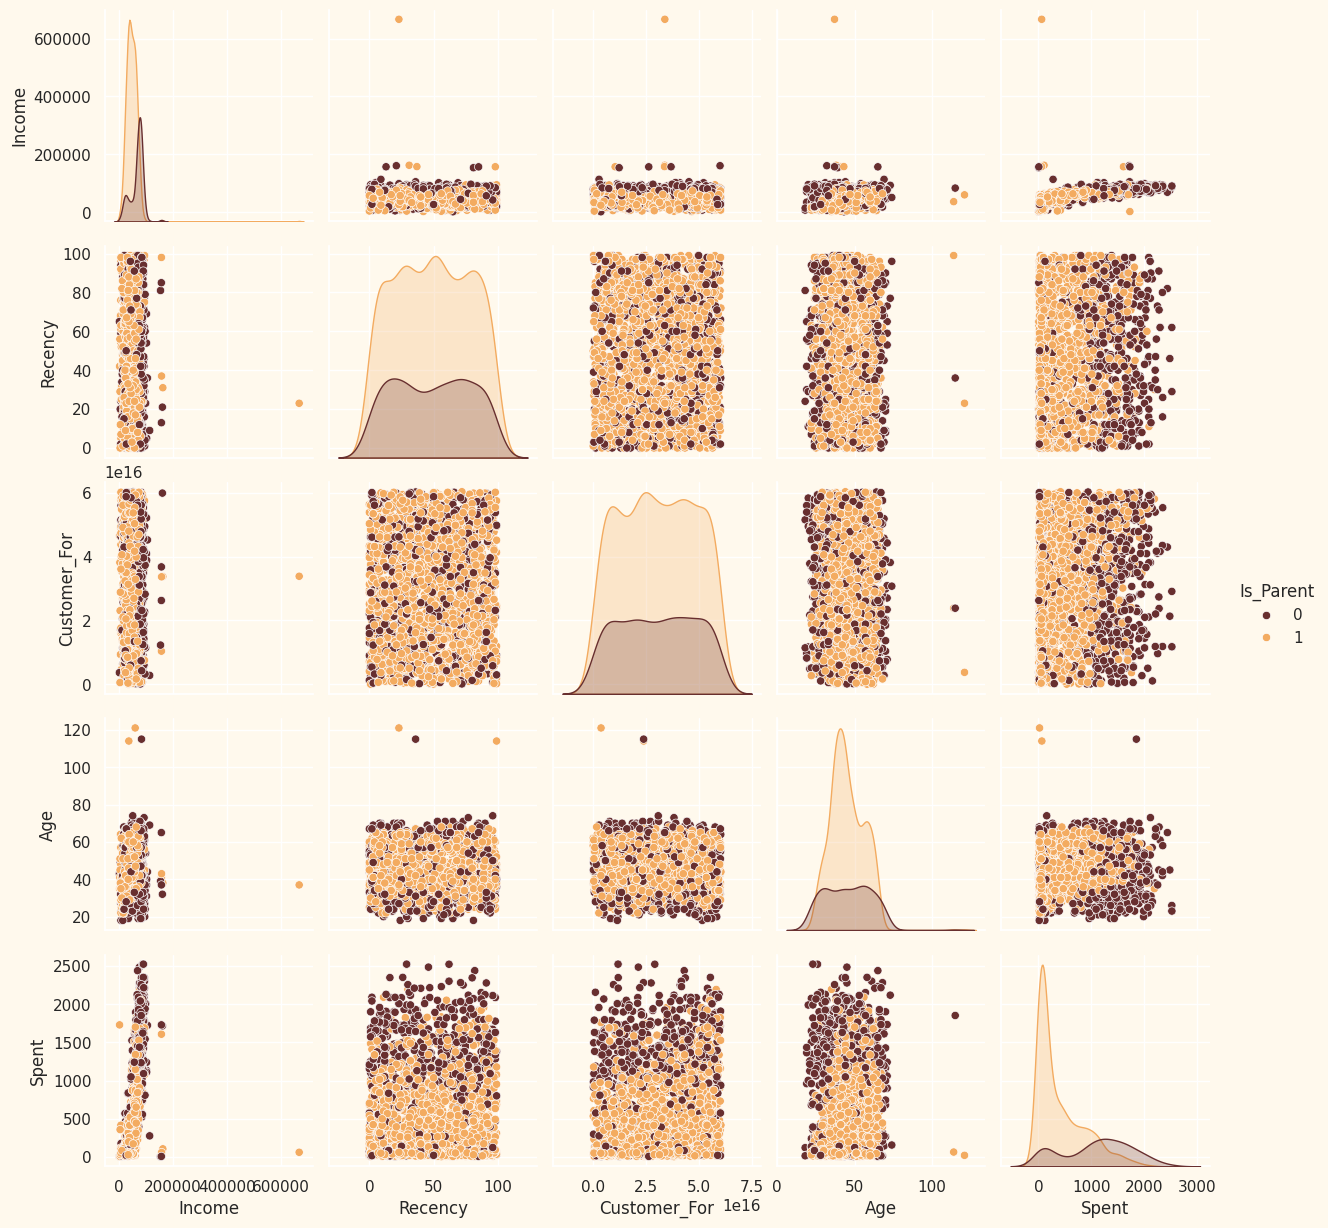

In [21]:
#To plot some selected features
#Setting up colors prefrences
sns.set(rc={"axes.facecolor":"#FFF9ED","figure.facecolor":"#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])
#Plotting following features
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Reletive Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent",palette= (["#682F2F","#F3AB60"]))
#Taking hue
plt.show()

In [23]:
#Dropping the outliers by setting a cap on Age and income.
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


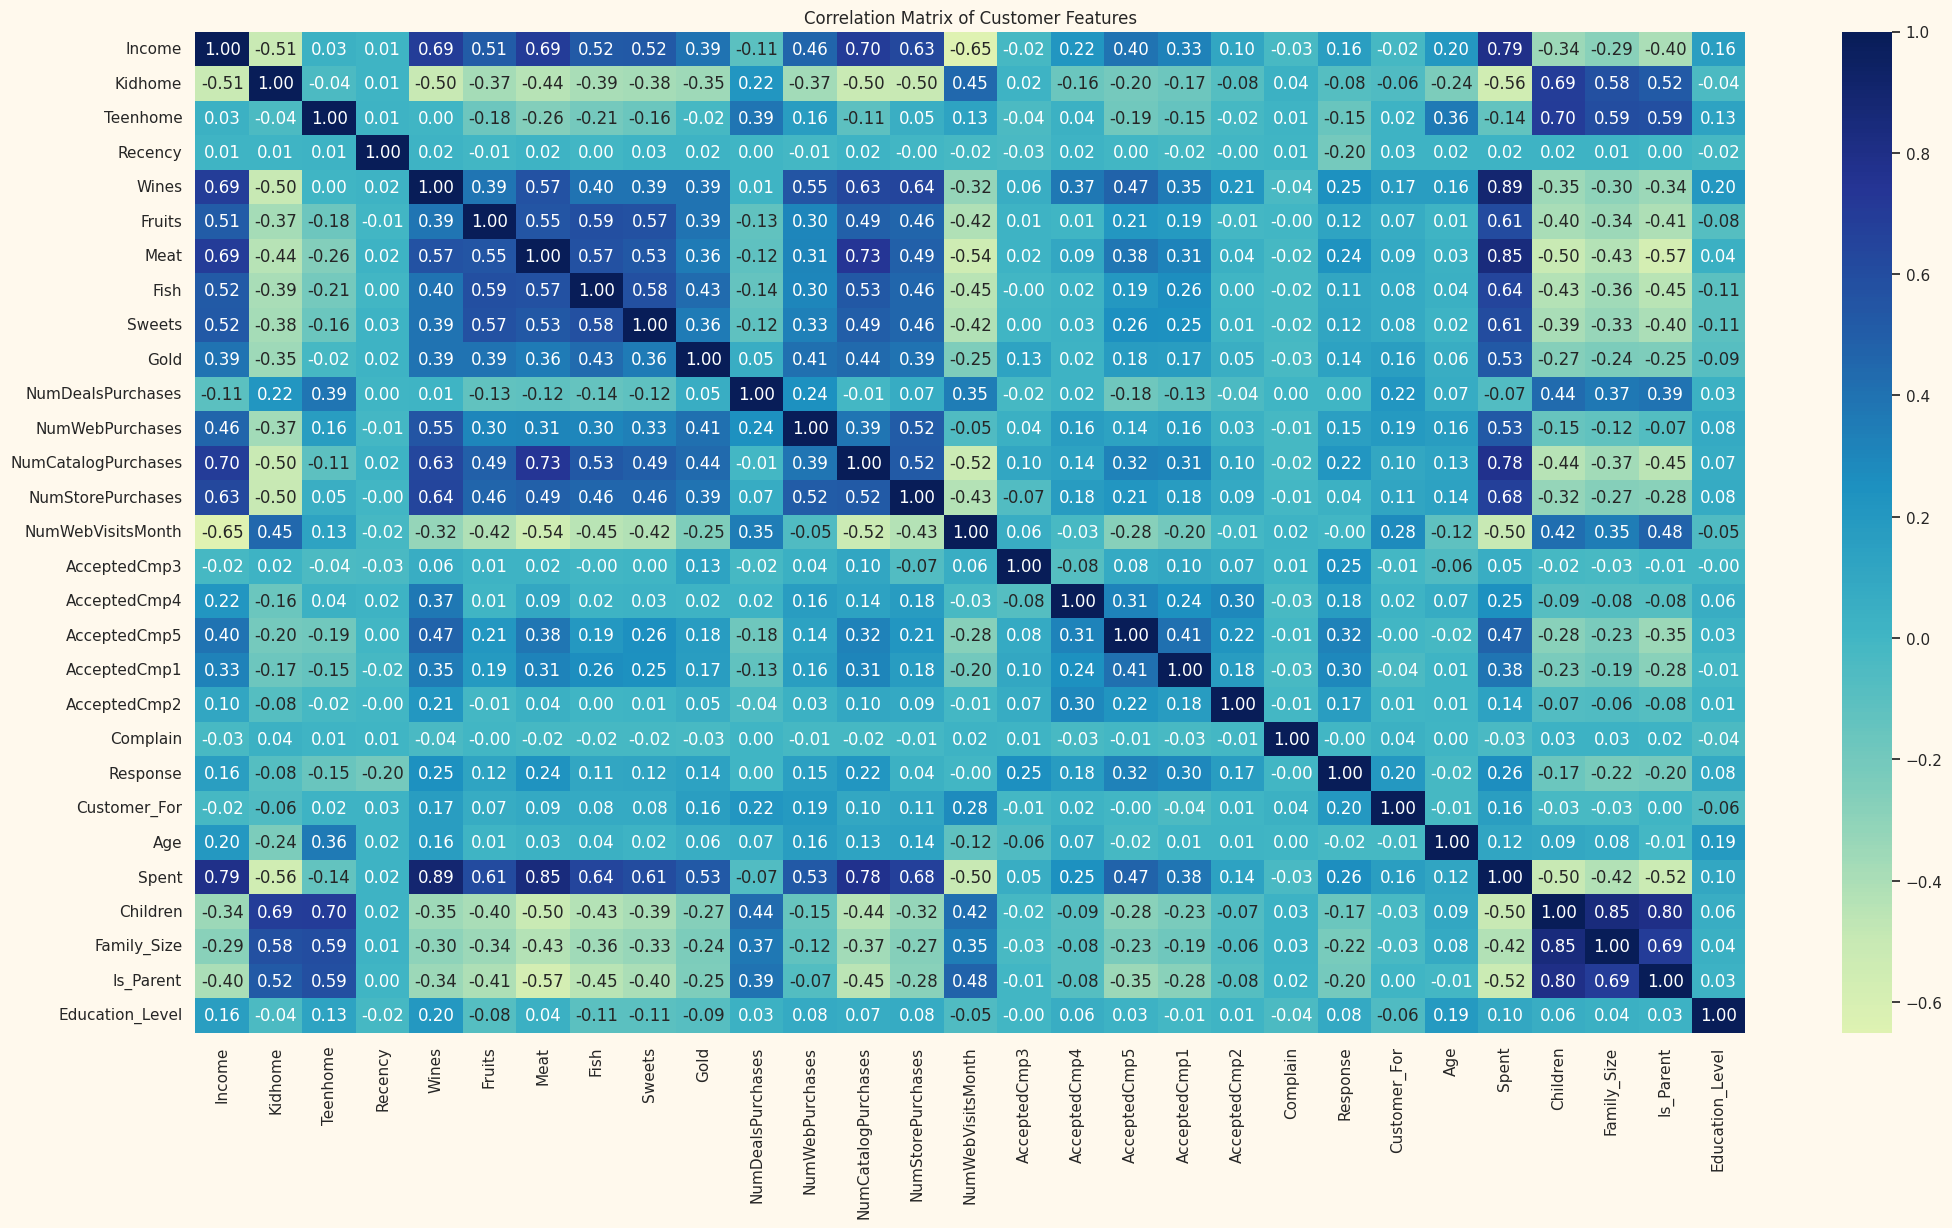

In [24]:
# Correlation matrix - numeric features only
numeric_data = data.select_dtypes(include='number')

corrmat = numeric_data.corr()

plt.figure(figsize=(25, 13))
sns.heatmap(
    corrmat,
    annot=True,
    center=0,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title('Correlation Matrix of Customer Features')
plt.show()

DATA PREPROCESSING

In [25]:
#Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [26]:
data[['Living_With','Education']]

,Living_With,Education
0,Alone,Graduate
1,Alone,Graduate
2,Partner,Graduate
3,Partner,Graduate
4,Partner,Postgraduate
...,...,...
2235,Partner,Graduate
2236,Partner,Postgraduate
2237,Alone,Graduate
2238,Partner,Postgraduate


In [27]:
# Education is already encoded ordinally above, so only the remaining
# categorical column needs encoding. Living_With is binary, so a label
# encoding introduces no false ordering.
LE = LabelEncoder()
for col in object_cols:
    if col == "Education":
        continue
    data[col] = LE.fit_transform(data[col])

# Drop the original text Education column now that Education_Level exists
data = data.drop(columns=["Education"])

print("All features are now numerical")
data[["Living_With", "Education_Level"]].head()

All features are now numerical


,Living_With,Education_Level
0,0,1
1,0,1
2,1,1
3,1,1
4,1,2


In [28]:
data[["Living_With", "Education_Level"]].head()

,Living_With,Education_Level
0,0,1
1,0,1
2,1,1
3,1,1
4,1,2


In [29]:
#Creating a copy of data
ds = data.copy()
# creating a subset of dataframe by dropping the features on deals accepted and promotions
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)

In [30]:
ds

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent,Education_Level
0,58138.0,0,0,58,635,88,546,172,88,88,...,4,7,57283200000000000,57,1617,0,0,1,0,1
1,46344.0,1,1,38,11,1,6,2,1,6,...,2,5,9763200000000000,60,27,0,2,3,1,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,10,4,26956800000000000,49,776,1,0,2,0,1
3,26646.0,1,0,26,11,4,20,10,3,5,...,4,6,12009600000000000,30,53,1,1,3,1,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,6,5,13910400000000000,33,422,1,1,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42,118,247,...,4,5,32918400000000000,47,1341,1,1,3,1,1
2236,64014.0,2,1,56,406,0,30,0,0,8,...,5,7,1641600000000000,68,444,1,3,5,1,2
2237,56981.0,0,0,91,908,48,217,32,12,24,...,13,6,13392000000000000,33,1241,0,0,1,0,1
2238,69245.0,0,1,8,428,30,214,80,30,61,...,10,3,13478400000000000,58,843,1,1,3,1,2


In [31]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2212 non-null   float64
 1   Kidhome              2212 non-null   int64  
 2   Teenhome             2212 non-null   int64  
 3   Recency              2212 non-null   int64  
 4   Wines                2212 non-null   int64  
 5   Fruits               2212 non-null   int64  
 6   Meat                 2212 non-null   int64  
 7   Fish                 2212 non-null   int64  
 8   Sweets               2212 non-null   int64  
 9   Gold                 2212 non-null   int64  
 10  NumDealsPurchases    2212 non-null   int64  
 11  NumWebPurchases      2212 non-null   int64  
 12  NumCatalogPurchases  2212 non-null   int64  
 13  NumStorePurchases    2212 non-null   int64  
 14  NumWebVisitsMonth    2212 non-null   int64  
 15  Customer_For         2212 non-null   int64 

In [32]:
#Scaling
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
scaled_ds

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent,Education_Level
0,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,0.852576,...,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139,-0.411675
1,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,-0.733642,...,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456,-0.411675
2,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,-0.037254,...,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139,-0.411675
3,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,-0.752987,...,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456,-0.411675
4,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,-0.559545,...,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456,1.123949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,0.430444,-0.822754,0.908097,-0.104347,1.197084,0.419540,0.066770,0.079461,2.213965,3.928291,...,-0.555814,-0.132545,0.134778,0.163575,1.218061,0.740959,0.069987,0.449070,0.632456,-0.411675
2208,0.560123,2.902796,0.908097,0.241237,0.298631,-0.662628,-0.611184,-0.687527,-0.658360,-0.694954,...,-0.248141,0.692181,-1.653326,1.958607,-0.271040,0.740959,2.739158,2.656499,0.632456,1.123949
2209,0.233347,-0.822754,-0.929699,1.450778,1.787156,0.545373,0.222878,-0.103155,-0.366260,-0.385448,...,2.213242,0.279818,-0.981552,-1.033114,1.052052,-1.349603,-1.264598,-1.758359,-1.581139,-0.411675
2210,0.803172,-0.822754,0.908097,-1.417564,0.363866,0.092373,0.209498,0.773403,0.071892,0.330284,...,1.290224,-0.957271,-0.976612,1.103830,0.391336,0.740959,0.069987,0.449070,0.632456,1.123949


In [33]:
scaled_ds.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent,Education_Level
count,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,...,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03,2.212000e+03
mean,-1.252765e-16,4.175884e-17,9.636656e-17,4.015273e-18,4.898633e-17,1.043971e-17,3.212219e-18,-1.204582e-17,3.212219e-18,9.636656e-18,...,-7.107033e-17,1.092154e-16,9.797266e-17,6.183521e-17,5.942604e-17,-2.730386e-17,2.248553e-17,2.505530e-16,1.606109e-17,3.212219e-17
std,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,...,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00
min,-2.333791e+00,-8.227535e-01,-9.296987e-01,-1.694030e+00,-9.052351e-01,-6.626279e-01,-7.449911e-01,-6.875269e-01,-6.583604e-01,-8.497071e-01,...,-1.786506e+00,-2.194360e+00,-1.747176e+00,-2.315280e+00,-9.998189e-01,-1.349603e+00,-1.264598e+00,-1.758359e+00,-1.581139e+00,-1.947299e+00
25%,-7.771113e-01,-8.227535e-01,-9.296987e-01,-8.646302e-01,-8.340705e-01,-6.122946e-01,-6.736275e-01,-6.327421e-01,-6.340186e-01,-6.756101e-01,...,-8.634873e-01,-9.572709e-01,-8.580640e-01,-6.912026e-01,-8.935732e-01,-1.349603e+00,-1.264598e+00,-6.546443e-01,-1.581139e+00,-4.116750e-01
50%,-2.731156e-02,-8.227535e-01,-9.296987e-01,-6.717941e-04,-3.848445e-01,-4.612945e-01,-4.416956e-01,-4.683875e-01,-4.636265e-01,-3.757762e-01,...,-2.481413e-01,2.798177e-01,1.129032e-02,-9.285849e-02,-3.490638e-01,7.409586e-01,6.998729e-02,4.490700e-01,6.324555e-01,-4.116750e-01
75%,7.679525e-01,1.040021e+00,9.080971e-01,8.632866e-01,5.921851e-01,1.678727e-01,2.908968e-01,2.255541e-01,1.449170e-01,2.335637e-01,...,6.748776e-01,6.921805e-01,8.658261e-01,8.473966e-01,7.316544e-01,7.409586e-01,6.998729e-02,4.490700e-01,6.324555e-01,1.123949e+00
max,5.131311e+00,2.902796e+00,2.745893e+00,1.727245e+00,3.521791e+00,4.345543e+00,6.948902e+00,4.042233e+00,5.719175e+00,5.359756e+00,...,2.213242e+00,6.052898e+00,1.705543e+00,2.471473e+00,3.183607e+00,7.409586e-01,2.739158e+00,2.656499e+00,6.324555e-01,1.123949e+00


CLUSTERING

      inertia  silhouette
k                        
2   36641.756       0.274
3   32103.892       0.210
4   29686.520       0.157
5   28487.875       0.145
6   27117.986       0.149
7   26192.546       0.143
8   25204.965       0.142
9   24759.193       0.142
10  23861.745       0.127

Highest silhouette at k=2 (0.274)


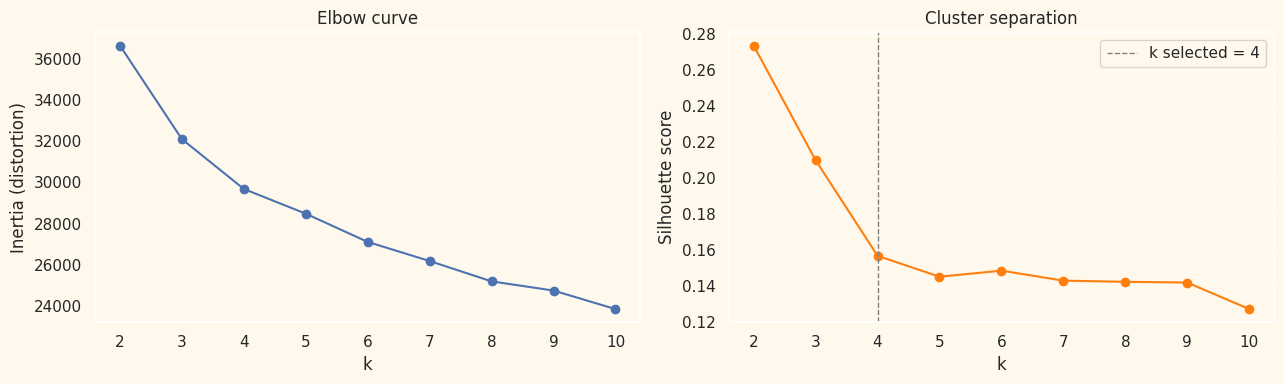

In [34]:
# Choosing k: inertia (elbow) alongside silhouette score.
#
# The elbow curve is read by eye and rarely gives an unambiguous answer,
# so silhouette is reported next to it as a numerical check on how well
# separated the resulting clusters actually are.

K_RANGE = range(2, 11)
inertia, silhouette = [], []

for k in K_RANGE:
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km_k.fit_predict(scaled_ds)
    inertia.append(km_k.inertia_)
    silhouette.append(silhouette_score(scaled_ds, labels_k))

k_table = pd.DataFrame(
    {"k": list(K_RANGE), "inertia": inertia, "silhouette": silhouette}
).set_index("k")
print(k_table.round(3))
print(f"\nHighest silhouette at k={k_table['silhouette'].idxmax()} "
      f"({k_table['silhouette'].max():.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(k_table.index, k_table["inertia"], marker="o")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia (distortion)")
ax1.set_title("Elbow curve"); ax1.grid(alpha=0.3)

ax2.plot(k_table.index, k_table["silhouette"], marker="o", color="tab:orange")
ax2.axvline(4, ls="--", c="grey", lw=1, label="k selected = 4")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette score")
ax2.set_title("Cluster separation"); ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.show()

### Selecting the Number of Clusters

The Elbow Method was used to determine the appropriate number of customer segments. Based on the distortion curve, **4 clusters** were selected for the K-Means model.

In [35]:
# K-Means with the selected number of clusters.
#
# Note: the cluster labels are NOT written back into scaled_ds. Adding the
# label to the matrix it was derived from would mean any later re-fit
# clusters on the answer itself.
K = 4

km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
yhat_km = km.fit_predict(scaled_ds)

data["Clusters"] = yhat_km

print(f"Fitted {K} clusters on {scaled_ds.shape[0]} customers "
      f"across {scaled_ds.shape[1]} features.")
print(data["Clusters"].value_counts().sort_index())

Fitted 4 clusters on 2212 customers across 23 features.
Clusters
0    508
1    585
2    510
3    609
Name: count, dtype: int64


EVALUATING MODELS

/tmp/ipykernel_1472/1397449635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data["Clusters"], palette= pal)


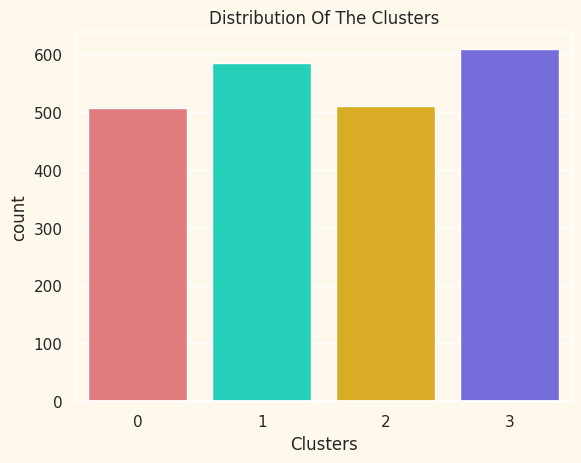

In [36]:
#Plotting countplot of clusters
pal = ["#f06c6e","#07edcb", "#f7bb07","#655beb"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

### Cluster Distribution

Segment sizes are quantified in the value-concentration table below rather
than described qualitatively, because the size of a segment determines how
much of the business it actually represents.

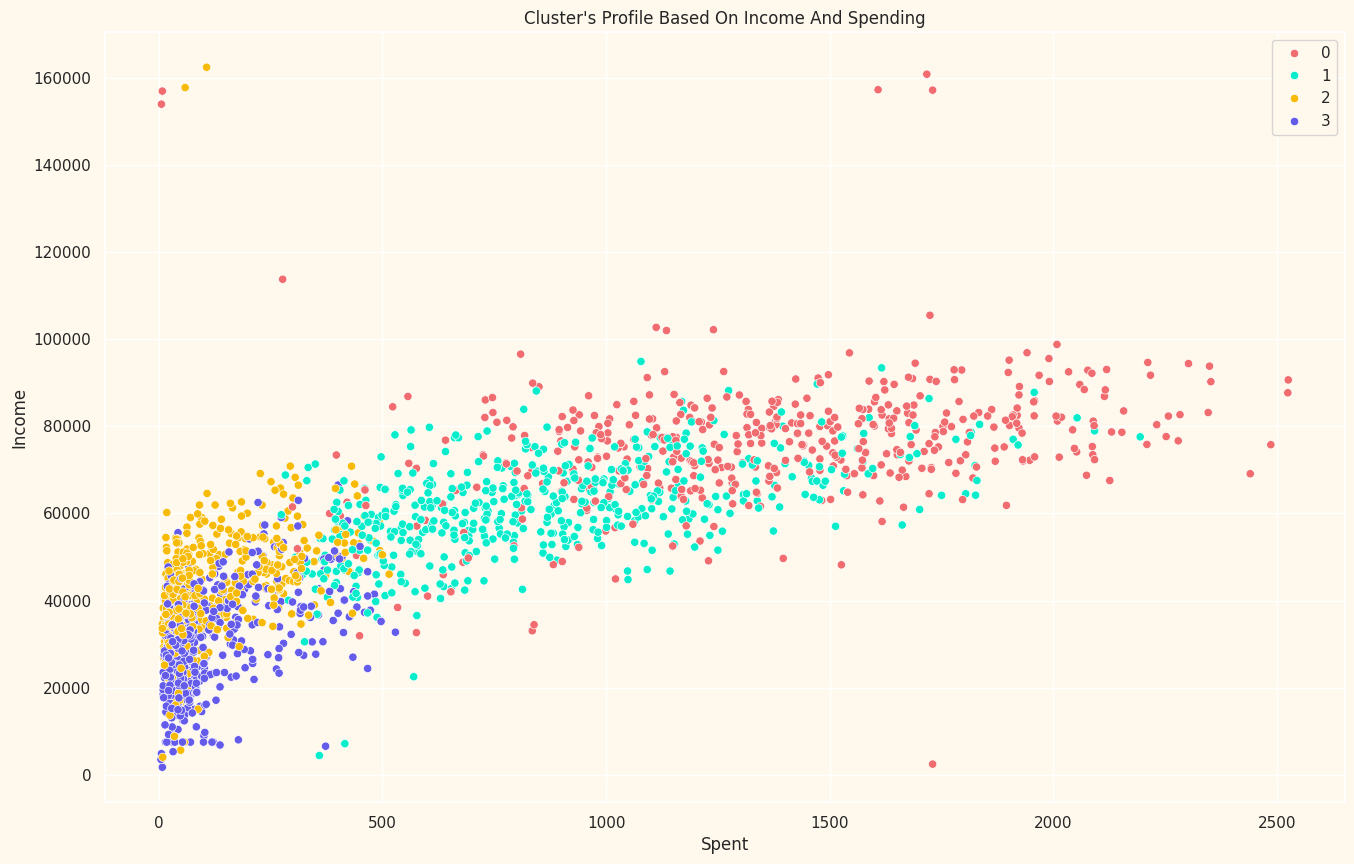

In [37]:
plt.figure(figsize = (16,10))
pl = sns.scatterplot(data = data,x=data["Spent"], y=data["Income"],hue=data["Clusters"], palette= pal)
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

In [38]:
# Customer profile summary by cluster

cluster_profile = data.groupby("Clusters")[
    [
        "Income",
        "Spent",
        "Age",
        "Children",
        "Family_Size",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth"
    ]
].mean().round(2)

cluster_profile

,Income,Spent,Age,Children,Family_Size,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Clusters,,,,,,,,,,
0,76173.33,1372.92,45.87,0.03,1.62,1.13,4.94,5.99,8.23,2.65
1,61730.94,873.86,48.54,1.13,2.80,3.46,6.61,3.66,8.28,5.42
2,42652.87,135.32,49.64,1.84,3.54,2.77,2.50,0.77,3.65,6.05
3,30166.29,107.74,37.30,0.79,2.42,1.86,2.29,0.55,3.21,6.84


---

## Segment Value Concentration

Average spending per segment does not tell a business where its revenue comes
from — that depends on how many customers each segment holds. The table below
pairs segment size with revenue contribution.

In [39]:
value = (
    data.groupby("Clusters")
    .agg(customers=("Clusters", "size"),
         avg_income=("Income", "mean"),
         avg_spend=("Spent", "mean"),
         median_spend=("Spent", "median"))
)
value["total_spend"] = value["customers"] * value["avg_spend"]
value["share_of_customers"] = value["customers"] / value["customers"].sum()
value["share_of_revenue"] = value["total_spend"] / value["total_spend"].sum()

# How much revenue a segment carries relative to its share of the base.
# 1.0 means proportional; above 1.0 means it punches above its weight.
value["revenue_index"] = value["share_of_revenue"] / value["share_of_customers"]

value = value.sort_values("avg_spend", ascending=False)

display_cols = ["customers", "share_of_customers", "avg_income", "avg_spend",
                "share_of_revenue", "revenue_index"]
print(value[display_cols].round(3).to_string())

top = value.index[0]
bottom = value.index[-1]
print(
    f"\nCluster {top}: {value.loc[top, 'share_of_customers']:.1%} of customers "
    f"generate {value.loc[top, 'share_of_revenue']:.1%} of total spending "
    f"({value.loc[top, 'revenue_index']:.2f}x their share of the base)."
)
print(
    f"Income spread across segments: "
    f"{value['avg_income'].max() / value['avg_income'].min():.1f}x. "
    f"Spending spread: {value['avg_spend'].max() / value['avg_spend'].min():.1f}x."
)

          customers  share_of_customers  avg_income  avg_spend  share_of_revenue  revenue_index
Clusters                                                                                       
0               508               0.230   76173.333   1372.919             0.519          2.261
1               585               0.264   61730.935    873.858             0.381          1.439
2               510               0.231   42652.875    135.320             0.051          0.223
3               609               0.275   30166.294    107.741             0.049          0.177

Cluster 0: 23.0% of customers generate 51.9% of total spending (2.26x their share of the base).
Income spread across segments: 2.5x. Spending spread: 12.7x.


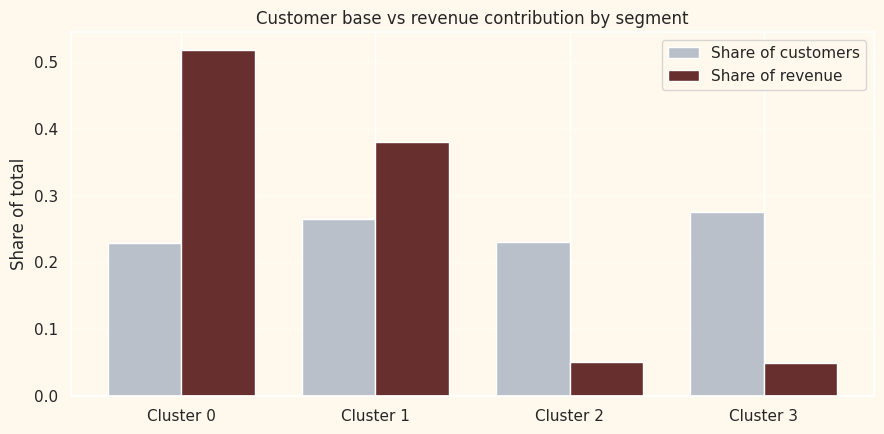

In [40]:
fig, ax = plt.subplots(figsize=(9, 4.5))
idx = np.arange(len(value)); w = 0.38
ax.bar(idx - w/2, value["share_of_customers"], w, label="Share of customers",
       color="#B9C0C9")
ax.bar(idx + w/2, value["share_of_revenue"], w, label="Share of revenue",
       color="#682F2F")
ax.set_xticks(idx)
ax.set_xticklabels([f"Cluster {i}" for i in value.index])
ax.set_ylabel("Share of total")
ax.set_title("Customer base vs revenue contribution by segment")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Cluster Stability

An unsupervised result has no ground truth to check against, so the first
reasonable question is whether the same segments appear when the algorithm
starts from a different random initialisation. The adjusted Rand index
compares label assignments across seeds: values near 1.0 mean the
segmentation is reproducible rather than an artefact of one run.

In [41]:
base_labels = data["Clusters"].to_numpy()
ari = []
for seed in [1, 7, 42, 99, 2024]:
    alt = KMeans(n_clusters=K, random_state=seed, n_init=10).fit_predict(scaled_ds)
    ari.append(adjusted_rand_score(base_labels, alt))

print("Adjusted Rand index across 5 seeds:", [round(a, 3) for a in ari])
print(f"Mean {np.mean(ari):.3f}, minimum {min(ari):.3f}")

Adjusted Rand index across 5 seeds: [1.0, 1.0, 1.0, 1.0, 1.0]
Mean 1.000, minimum 1.000


## Web Conversion by Segment

Cluster 3 is described elsewhere as visiting the site often while buying
little. Purchases per visit turns that observation into a measured quantity
and shows how wide the gap actually is.

In [42]:
conv = data.groupby("Clusters").agg(
    web_purchases=("NumWebPurchases", "mean"),
    catalog_purchases=("NumCatalogPurchases", "mean"),
    store_purchases=("NumStorePurchases", "mean"),
    web_visits=("NumWebVisitsMonth", "mean"),
)
conv["purchases_per_visit"] = conv["web_purchases"] / conv["web_visits"]

channels = ["web_purchases", "catalog_purchases", "store_purchases"]
mix = conv[channels].div(conv[channels].sum(axis=1), axis=0)
mix.columns = [c.replace("_purchases", "_share") for c in channels]

print(pd.concat([conv.round(2), mix.round(3)], axis=1).to_string())

worst = conv["purchases_per_visit"].idxmin()
best = conv["purchases_per_visit"].idxmax()
print(
    f"\nCluster {worst} converts {conv.loc[worst, 'purchases_per_visit']:.2f} "
    f"web purchases per visit against {conv.loc[best, 'purchases_per_visit']:.2f} "
    f"for Cluster {best} — a "
    f"{conv.loc[best, 'purchases_per_visit'] / conv.loc[worst, 'purchases_per_visit']:.1f}x gap."
)

          web_purchases  catalog_purchases  store_purchases  web_visits  purchases_per_visit  web_share  catalog_share  store_share
Clusters                                                                                                                           
0                  4.94               5.99             8.23        2.65                 1.87      0.258          0.312        0.429
1                  6.61               3.66             8.28        5.42                 1.22      0.356          0.197        0.447
2                  2.50               0.77             3.65        6.05                 0.41      0.361          0.111        0.527
3                  2.29               0.55             3.21        6.84                 0.33      0.378          0.090        0.532

Cluster 3 converts 0.33 web purchases per visit against 1.87 for Cluster 0 — a 5.6x gap.


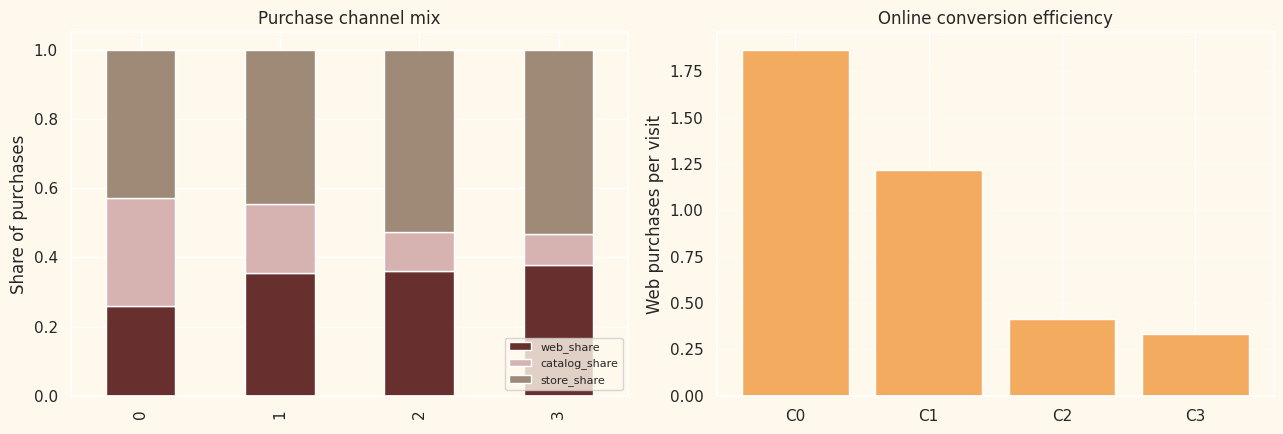

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
mix.plot(kind="bar", stacked=True, ax=ax1,
         color=["#682F2F", "#D6B2B1", "#9F8A78"])
ax1.set_ylabel("Share of purchases"); ax1.set_xlabel("")
ax1.set_title("Purchase channel mix"); ax1.legend(loc="lower right", fontsize=8)

ax2.bar([f"C{i}" for i in conv.index], conv["purchases_per_visit"],
        color="#F3AB60")
ax2.set_ylabel("Web purchases per visit")
ax2.set_title("Online conversion efficiency"); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Campaign Responsiveness

Segments are only useful for marketing if they respond differently to it.
Acceptance rates are compared against the overall rate, since a segment
matters here only where it deviates from the base.

In [44]:
CMP_COLS = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
            "AcceptedCmp4", "AcceptedCmp5"]
data["Total_Promos"] = data[CMP_COLS].sum(axis=1)

resp = data.groupby("Clusters").agg(
    avg_campaigns_accepted=("Total_Promos", "mean"),
    any_campaign_rate=("Total_Promos", lambda s: (s > 0).mean()),
    last_campaign_rate=("Response", "mean"),
    deals_purchases=("NumDealsPurchases", "mean"),
)

overall = (data["Total_Promos"] > 0).mean()
resp["lift_vs_overall"] = resp["any_campaign_rate"] - overall

print(resp.round(3).to_string())
print(f"\nOverall campaign acceptance rate: {overall:.1%}")

          avg_campaigns_accepted  any_campaign_rate  last_campaign_rate  deals_purchases  lift_vs_overall
Clusters                                                                                                 
0                          0.728              0.433               0.309            1.132            0.226
1                          0.316              0.232               0.113            3.456            0.025
2                          0.100              0.096               0.075            2.767           -0.111
3                          0.089              0.087               0.118            1.862           -0.120

Overall campaign acceptance rate: 20.7%


## Segment Profile, Indexed

Raw means are hard to compare across features on different scales. Indexing
each feature to the overall average makes the defining characteristic of
each segment readable at a glance: 1.00 is average, 1.50 is fifty percent
above it.

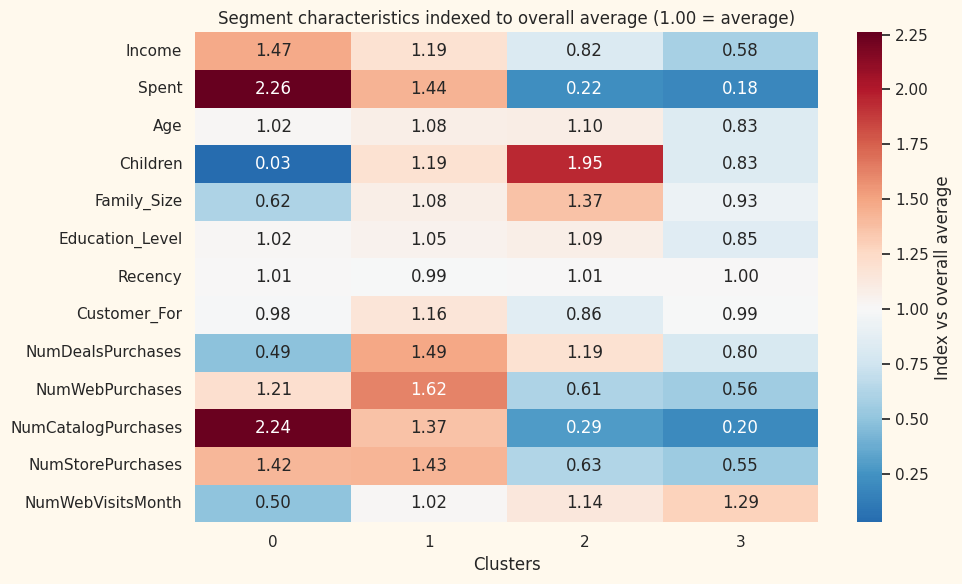

Clusters,0,1,2,3
Income,1.47,1.19,0.82,0.58
Spent,2.26,1.44,0.22,0.18
Age,1.02,1.08,1.10,0.83
Children,0.03,1.19,1.95,0.83
Family_Size,0.62,1.08,1.37,0.93
Education_Level,1.02,1.05,1.09,0.85
Recency,1.01,0.99,1.01,1.00
Customer_For,0.98,1.16,0.86,0.99
NumDealsPurchases,0.49,1.49,1.19,0.80
NumWebPurchases,1.21,1.62,0.61,0.56


In [45]:
PROFILE_COLS = ["Income", "Spent", "Age", "Children", "Family_Size",
                "Education_Level", "Recency", "Customer_For",
                "NumDealsPurchases", "NumWebPurchases",
                "NumCatalogPurchases", "NumStorePurchases",
                "NumWebVisitsMonth"]
PROFILE_COLS = [c for c in PROFILE_COLS if c in data.columns]

means = data.groupby("Clusters")[PROFILE_COLS].mean()
overall_mean = data[PROFILE_COLS].mean().replace(0, np.nan)
indexed = (means / overall_mean).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(indexed.T, annot=True, fmt=".2f", center=1.0, cmap="RdBu_r",
            cbar_kws={"label": "Index vs overall average"}, ax=ax)
ax.set_title("Segment characteristics indexed to overall average (1.00 = average)")
plt.tight_layout(); plt.show()

indexed.T

## Segments in Principal Component Space

A two-dimensional projection of the clustering features. The variance figure
in the axis labels matters: if the two components capture only part of the
total variance, the plot is a partial view of the separation, not proof of it.

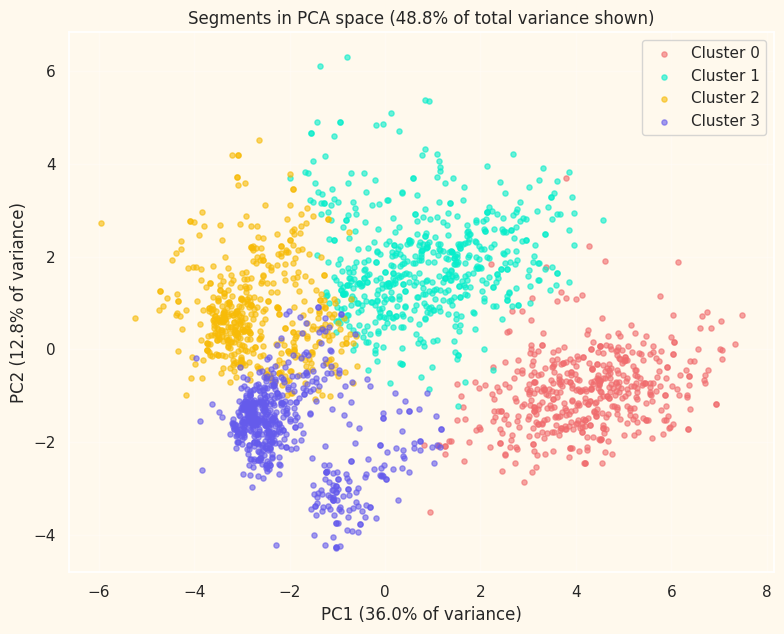

In [46]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(scaled_ds)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in sorted(data["Clusters"].unique()):
    m = base_labels == c
    ax.scatter(coords[m, 0], coords[m, 1], s=14, alpha=0.6,
               color=pal[c], label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({var[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1%} of variance)")
ax.set_title(f"Segments in PCA space ({var.sum():.1%} of total variance shown)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Sizing the Conversion Opportunity

The figure below is an illustration, not a forecast. It converts the
conversion gap into a revenue number so the opportunity can be compared
against the cost of acting on it — the question a marketing budget owner
would ask next.

In [47]:
GAP_CLUSTER = int(conv["purchases_per_visit"].idxmin())
UPLIFT = 0.10   # deliberately conservative, and an assumption rather than a result

seg = value.loc[GAP_CLUSTER]
incremental = seg["total_spend"] * UPLIFT
total = value["total_spend"].sum()

print(
    f"Cluster {GAP_CLUSTER} holds {seg['customers']:.0f} customers "
    f"({seg['share_of_customers']:.1%} of the base) contributing "
    f"{seg['share_of_revenue']:.1%} of revenue.\n"
    f"A {UPLIFT:.0%} lift in their spending would raise total revenue by "
    f"{incremental / total:.2%}.\n\n"
    "This sizes the opportunity under a stated assumption; it does not "
    "predict that the lift is achievable."
)

Cluster 3 holds 609 customers (27.5% of the base) contributing 4.9% of revenue.
A 10% lift in their spending would raise total revenue by 0.49%.

This sizes the opportunity under a stated assumption; it does not predict that the lift is achievable.


### Customer Segment Profiles

**Cluster 0 — Family-Oriented Low-Spending Customers**
- Medium income with relatively low spending
- Largest family size and highest number of children
- Potentially more price-sensitive and family-focused

**Cluster 1 — Active Mid-to-High Value Customers**
- Mid-to-high income with high spending
- Highly active across web and store channels
- Highest usage of promotional deals

**Cluster 2 — High-Value Customers**
- Highest average income and spending
- Strong catalog and store purchasing behavior
- Very few children and smaller households
- Strong potential for premium and loyalty campaigns

**Cluster 3 — Low-Value / Low-Engagement Customers**
- Lowest average income and spending
- High website visits but relatively low purchasing activity
- Potential opportunity to improve conversion through targeted offers

## Business Recommendations

Based on the customer segmentation results, different marketing strategies can be applied to each customer group.

### Cluster 0 — Family-Oriented Low-Spending Customers
- Offer family bundles and value-for-money packages.
- Use discounts and family-focused promotions to encourage higher spending.
- Recommend products that match larger household needs.

### Cluster 1 — Active Mid-to-High Value Customers
- Use cross-channel campaigns across web and physical stores.
- Provide loyalty rewards and personalized promotions.
- Apply upselling and cross-selling strategies to increase customer value.

### Cluster 2 — High-Value Customers
- Prioritize customer retention through VIP or loyalty programs.
- Recommend premium products and personalized offers.
- Provide exclusive campaigns to maintain engagement with these high-value customers.

### Cluster 3 — Low-Value / Low-Engagement Customers
- Focus on converting website visits into purchases.
- Test targeted discounts or entry-level offers.
- Use retargeting campaigns for customers who visit frequently but purchase less.

## Business Impact

Customer segmentation allows the business to move away from a one-size-fits-all marketing strategy.

By understanding differences in customer income, spending behavior, household characteristics, and purchasing channels, marketing strategies can be tailored to each segment.

This can support more effective customer targeting, campaign planning, customer retention, and marketing resource allocation.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 51.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_1472/1915540243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/

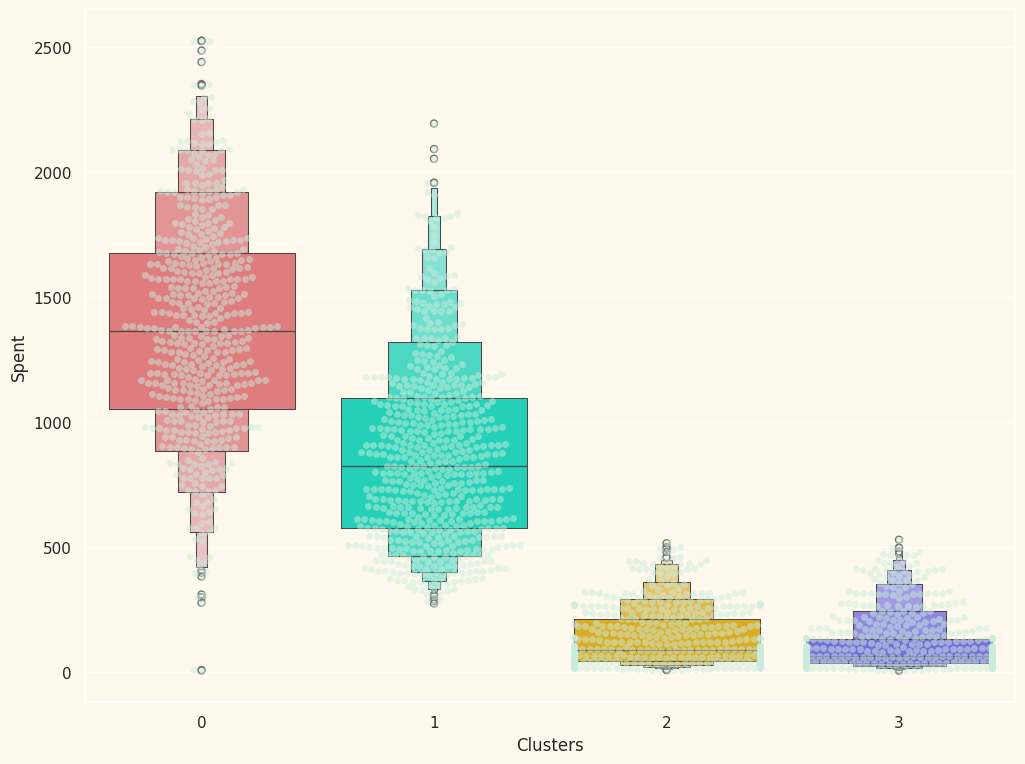

In [48]:
plt.figure(figsize = (12,9))
pl=sns.swarmplot(x=data["Clusters"], y=data["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show()

## Spending Behaviour by Customer Segment

Spending distributions differ sharply across segments. Cluster 2 holds the
highest-value customers, followed by Cluster 1, while Clusters 0 and 3 sit
substantially lower. The spread within each segment matters as much as the
mean: a segment with a long right tail contains customers whose behaviour
the segment average does not describe.

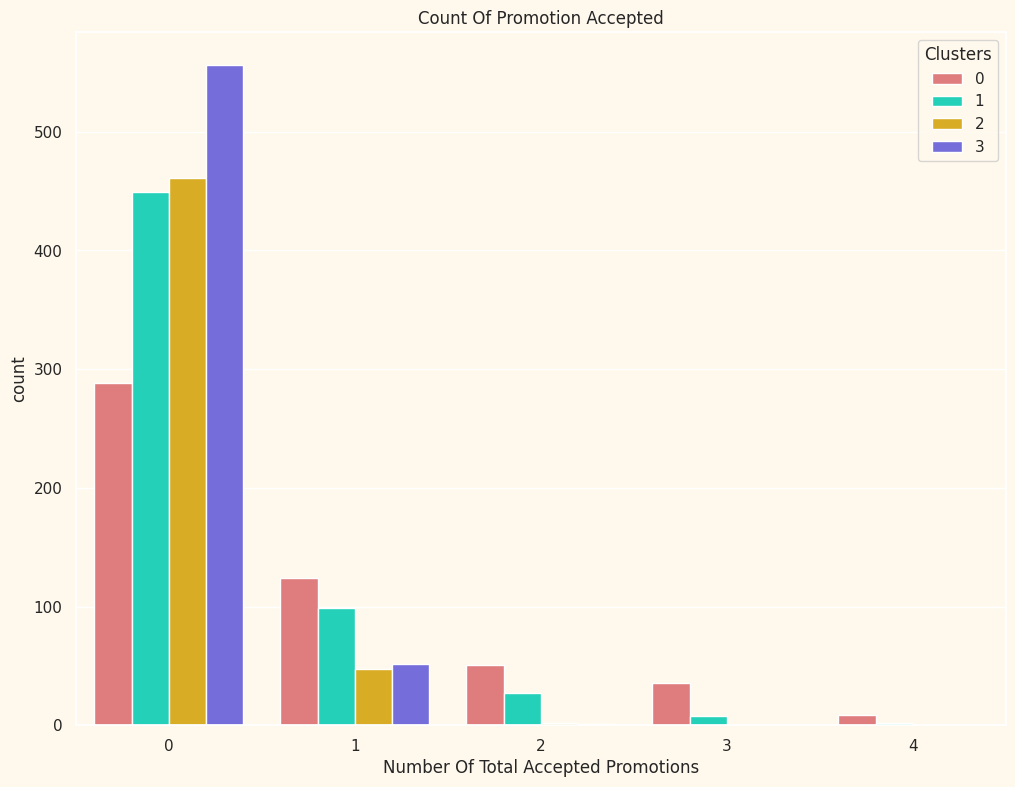

In [49]:
#Creating a feature to get a sum of accepted promotions
data["Total_Promos"] = data["AcceptedCmp1"]+ data["AcceptedCmp2"]+ data["AcceptedCmp3"]+ data["AcceptedCmp4"]+ data["AcceptedCmp5"]
#Plotting count of total campaign accepted.
plt.figure(figsize = (12,9))
pl = sns.countplot(x=data["Total_Promos"],hue=data["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

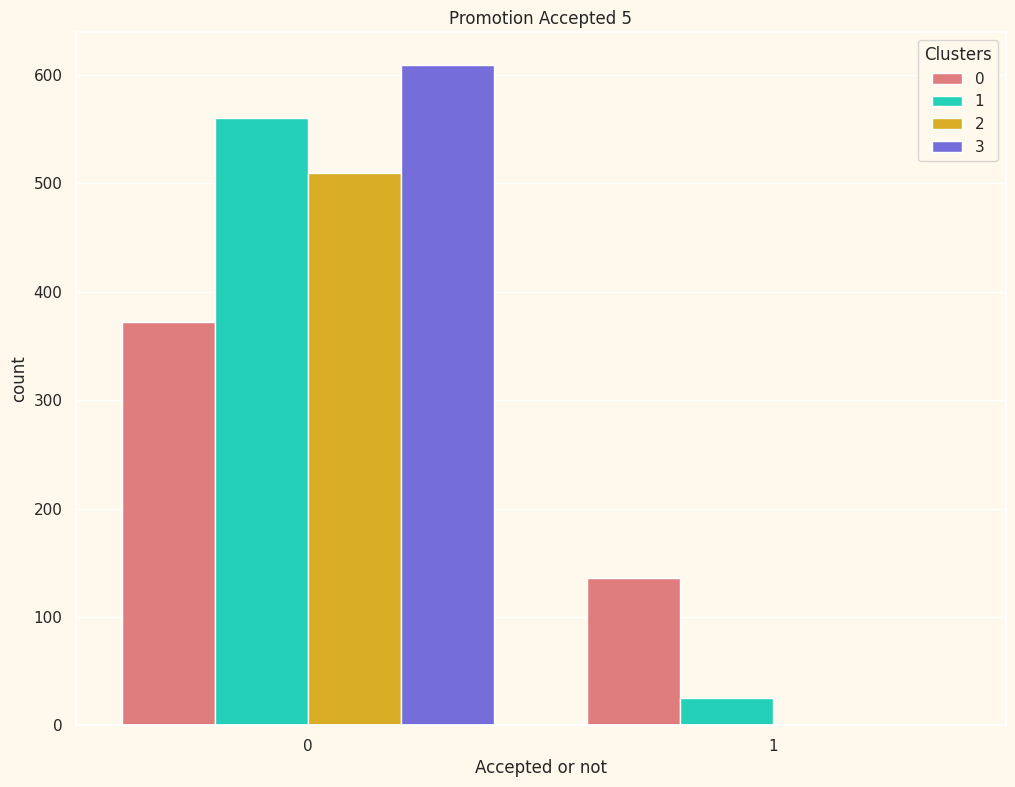

In [50]:
plt.figure(figsize = (12,9))
pl = sns.countplot(x=data["AcceptedCmp5"],hue=data["Clusters"], palette= pal)
pl.set_title("Promotion Accepted 5")
pl.set_xlabel("Accepted or not")
plt.show()

/tmp/ipykernel_1472/2570238648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)


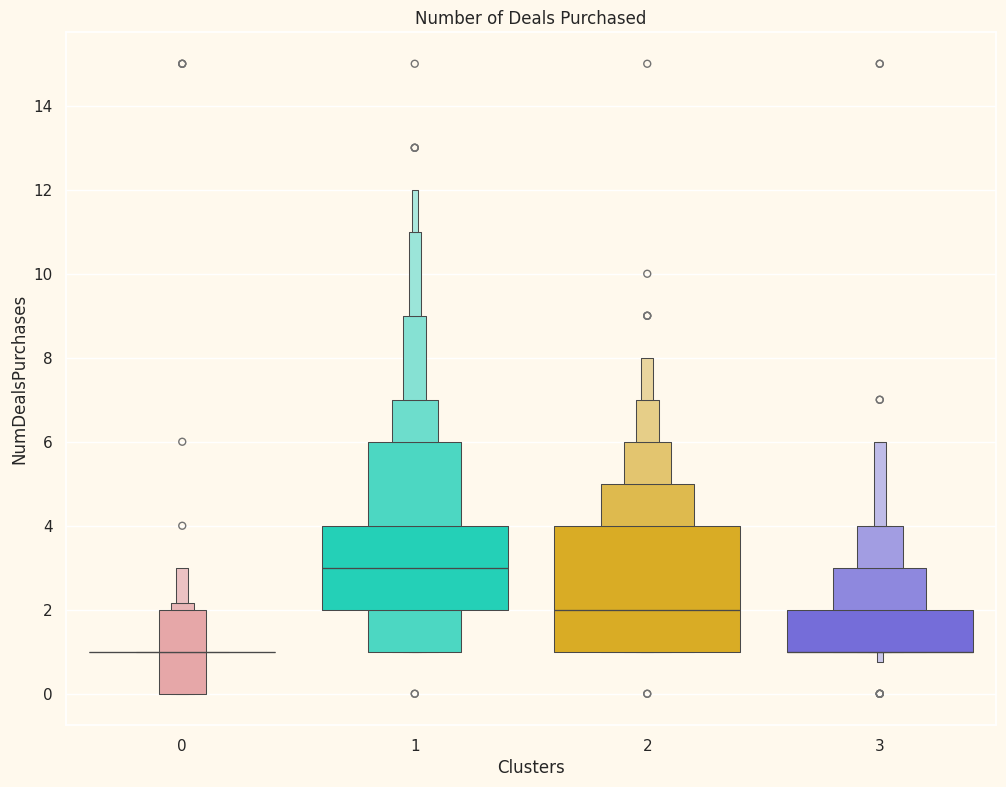

In [51]:
#Plotting the number of deals purchased
plt.figure(figsize = (12,9))
pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)
pl.set_title("Number of Deals Purchased")
plt.show()

### Customer Profiles Based on Income and Spending

The customer segments show clear differences in economic value and spending behavior.

- **Cluster 0:** Medium-income customers with relatively low spending.
- **Cluster 1:** Mid-to-high income customers with high spending.
- **Cluster 2:** Highest-income and highest-spending customers.
- **Cluster 3:** Lowest-income customers with relatively low spending.

These differences suggest that customer value varies significantly across segments and that different marketing strategies should be applied to each group.

/tmp/ipykernel_1472/2141744595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["Spent"],x=data["Clusters"], palette= pal)


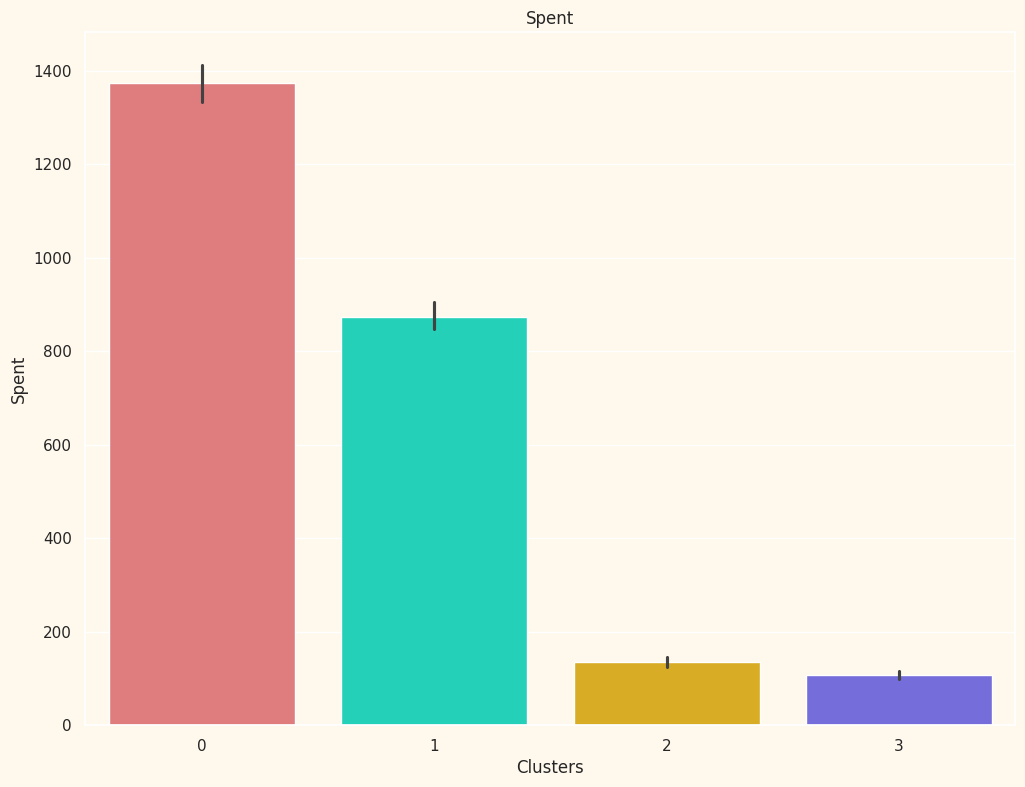

In [52]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["Spent"],x=data["Clusters"], palette= pal)
pl.set_title("Spent")
plt.show()

In [53]:
data["numtotal"] = data['NumDealsPurchases'] + data['NumWebPurchases'] + data['NumCatalogPurchases'] + data['NumStorePurchases']

/tmp/ipykernel_1472/354566178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["numtotal"],x=data["Clusters"], palette= pal)


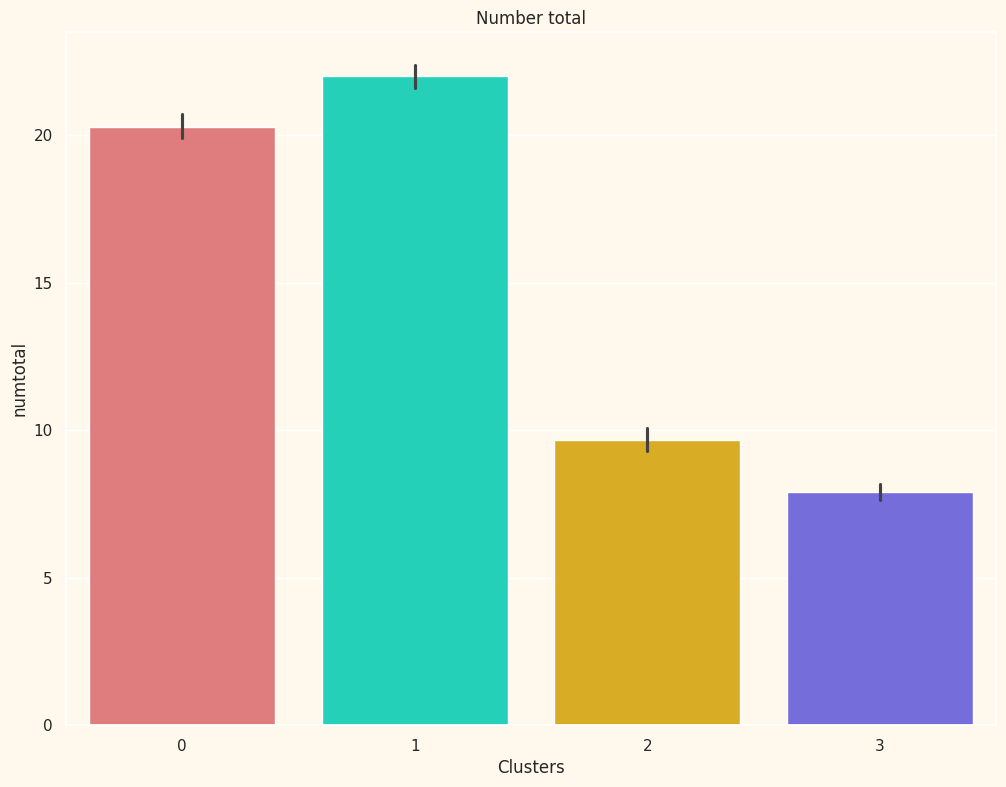

In [54]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["numtotal"],x=data["Clusters"], palette= pal)
pl.set_title("Number total")
plt.show()

### Online Purchasing Behavior

Customer segments demonstrate different levels of online engagement and purchasing activity.

Cluster 1 shows strong online purchasing activity, while Cluster 3 visits the website frequently but makes relatively fewer online purchases.

This indicates a potential **conversion opportunity** for Cluster 3. Targeted offers, retargeting campaigns, or improvements to the online customer journey could help convert browsing activity into purchases.

/tmp/ipykernel_1472/2073531949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["NumWebPurchases"],x=data["Clusters"], palette= pal)


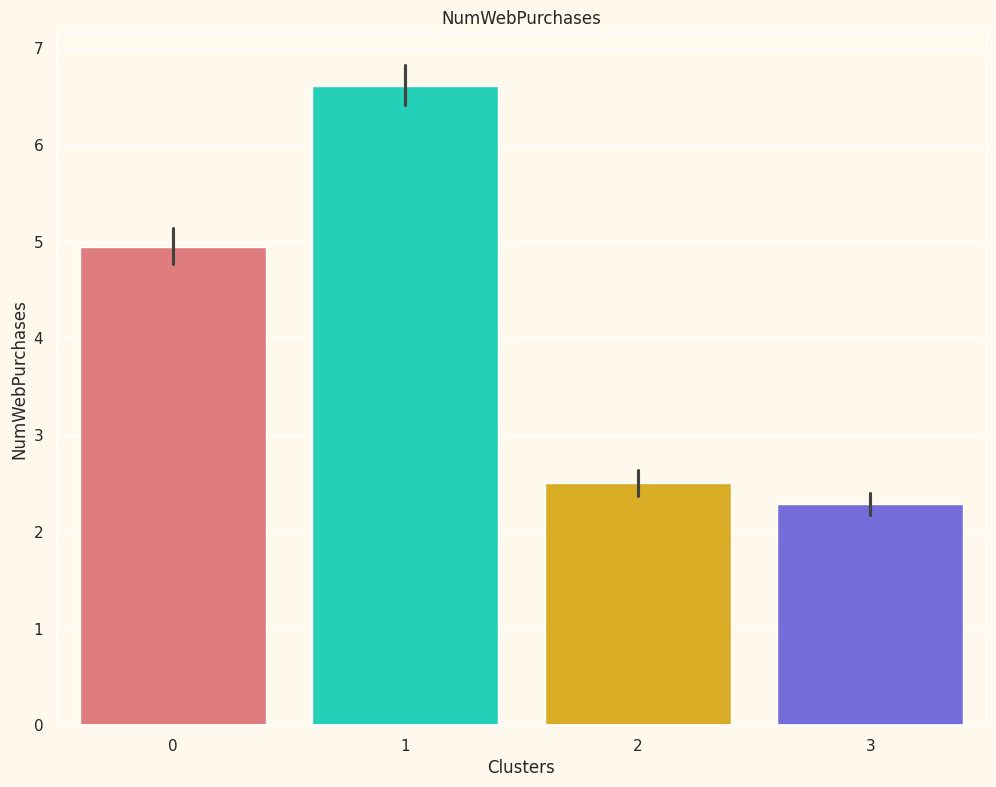

In [55]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["NumWebPurchases"],x=data["Clusters"], palette= pal)
pl.set_title("NumWebPurchases")
plt.show()

/tmp/ipykernel_1472/2818036359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["NumWebVisitsMonth"],x=data["Clusters"], palette= pal)


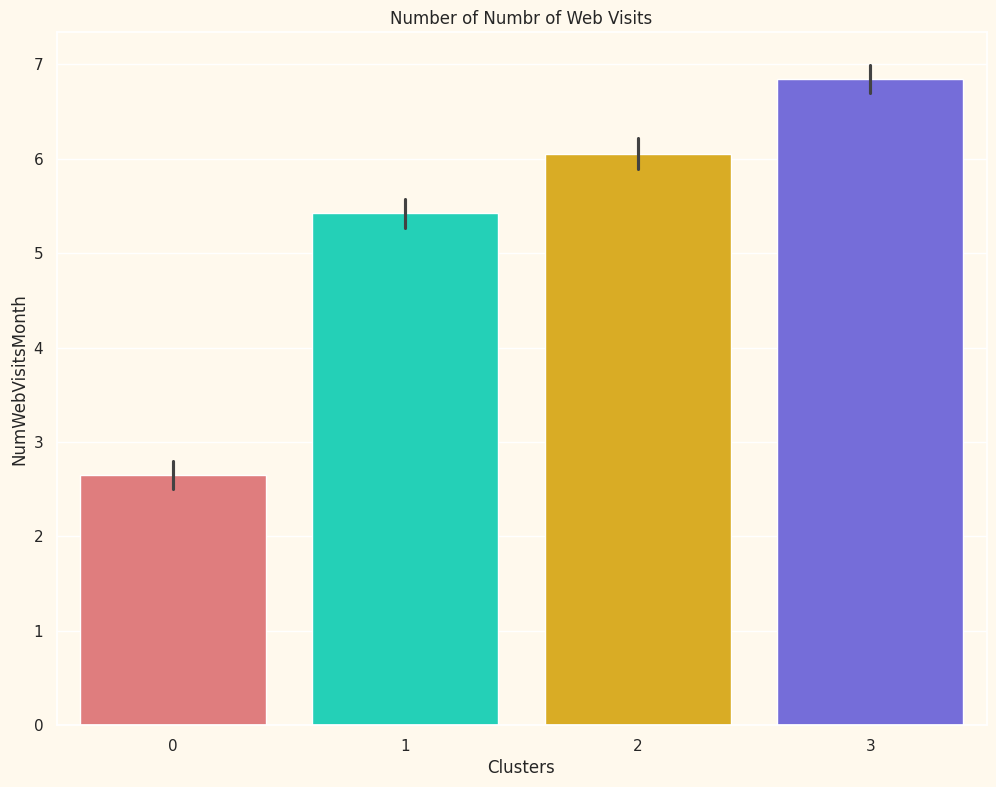

In [56]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["NumWebVisitsMonth"],x=data["Clusters"], palette= pal)
pl.set_title("Number of Numbr of Web Visits")
plt.show()

### Household Characteristics

Cluster 0 has the largest average family size and the highest number of children among the customer segments.

This suggests that Cluster 0 can be considered a more **family-oriented customer segment**.

Family bundles, value-for-money packages, and household-focused promotions may therefore be more relevant for this group.

/tmp/ipykernel_1472/3131575838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.barplot(y=data["Family_Size"],x=data["Clusters"], palette= pal)


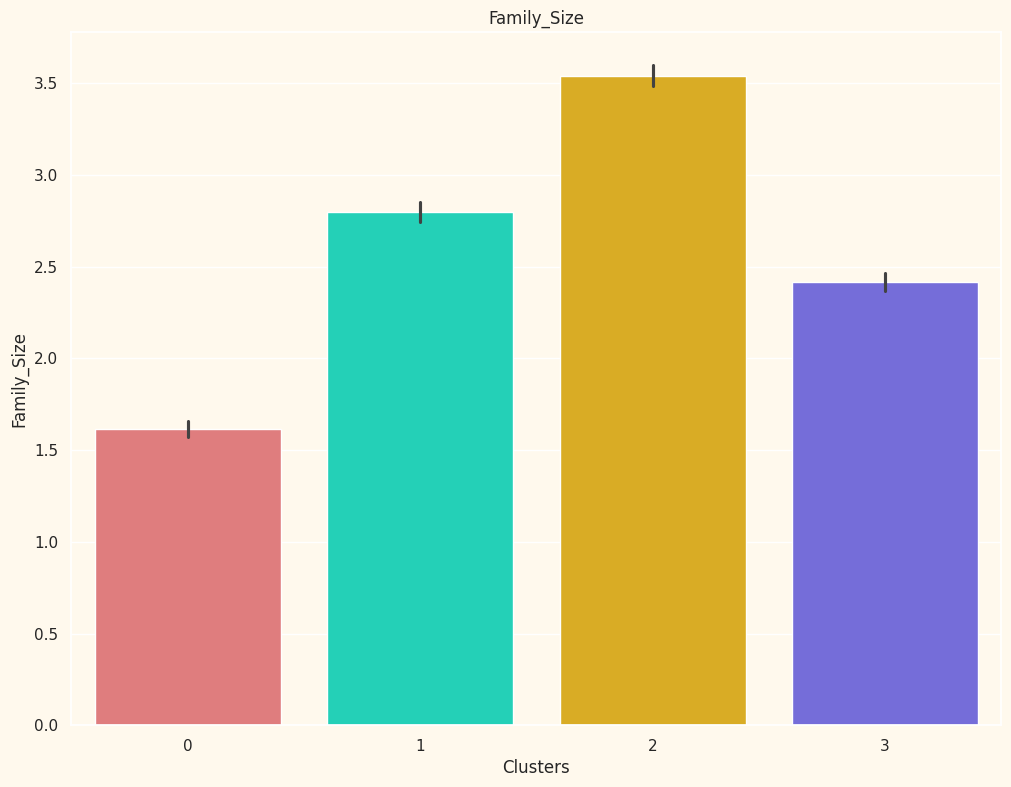

In [57]:
plt.figure(figsize = (12,9))
pl=sns.barplot(y=data["Family_Size"],x=data["Clusters"], palette= pal)
pl.set_title("Family_Size")
plt.show()

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2212 non-null   float64
 1   Kidhome              2212 non-null   int64  
 2   Teenhome             2212 non-null   int64  
 3   Recency              2212 non-null   int64  
 4   Wines                2212 non-null   int64  
 5   Fruits               2212 non-null   int64  
 6   Meat                 2212 non-null   int64  
 7   Fish                 2212 non-null   int64  
 8   Sweets               2212 non-null   int64  
 9   Gold                 2212 non-null   int64  
 10  NumDealsPurchases    2212 non-null   int64  
 11  NumWebPurchases      2212 non-null   int64  
 12  NumCatalogPurchases  2212 non-null   int64  
 13  NumStorePurchases    2212 non-null   int64  
 14  NumWebVisitsMonth    2212 non-null   int64  
 15  AcceptedCmp3         2212 non-null   int64 

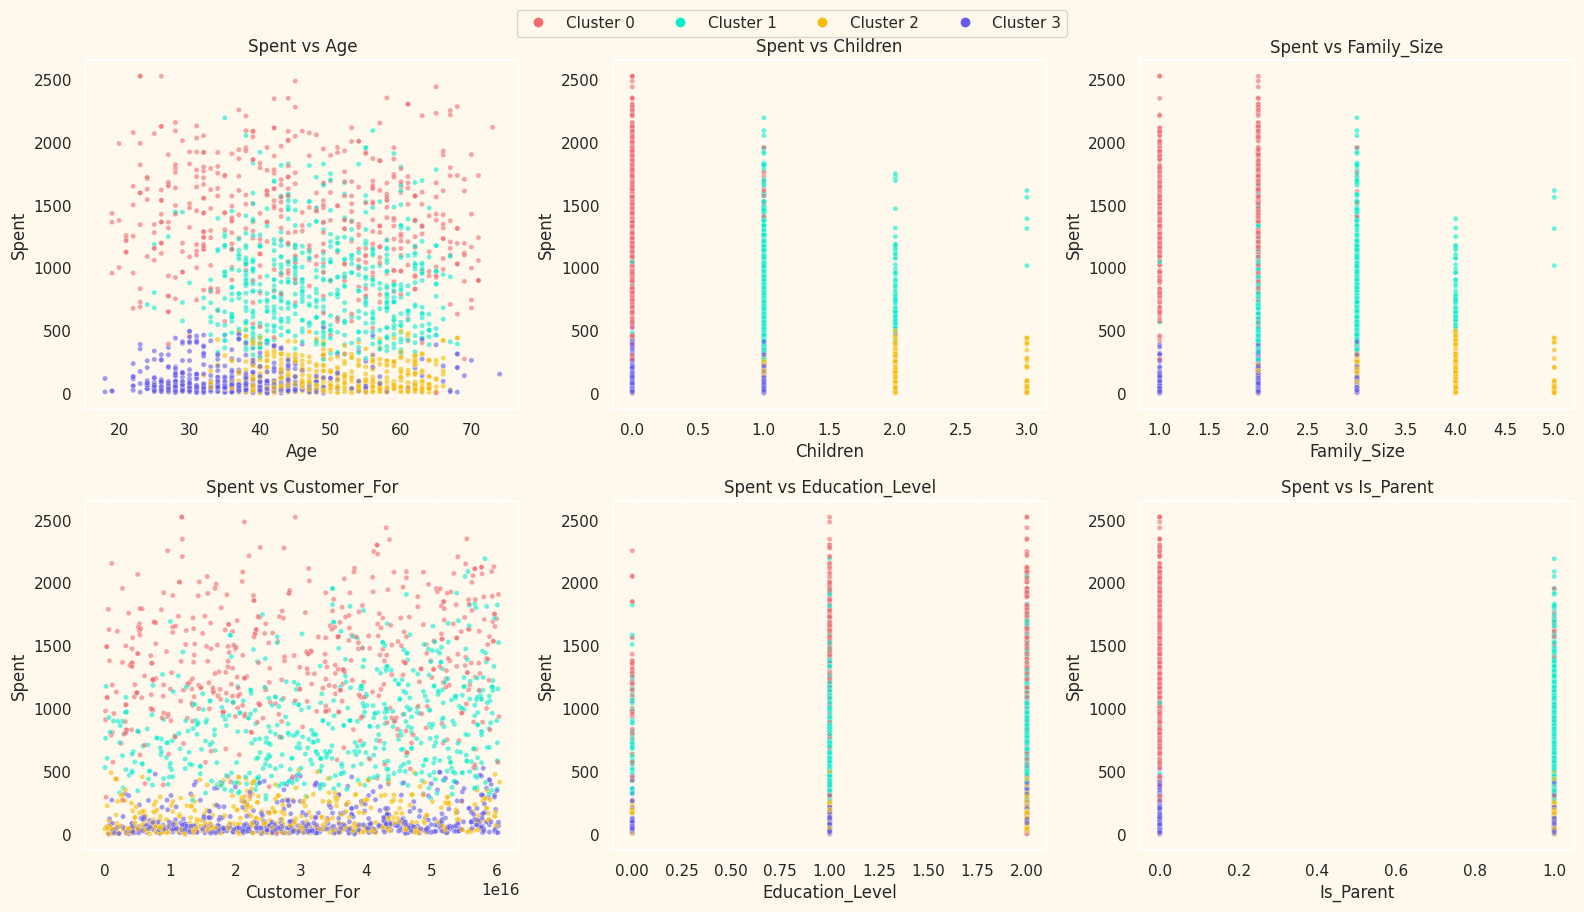

In [59]:
# Relationship between household characteristics and spending, by segment.
# Reduced from eighteen jointplots to one faceted view: the earlier version
# produced near-duplicate charts and inflated the notebook to several MB.

PERSONAL = ["Age", "Children", "Family_Size", "Customer_For",
            "Education_Level", "Is_Parent"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), PERSONAL):
    sns.scatterplot(data=data, x=col, y="Spent", hue="Clusters",
                    palette=pal, s=14, alpha=0.6, ax=ax, legend=False)
    ax.set_title(f"Spent vs {col}")
    ax.grid(alpha=0.3)

handles = [plt.Line2D([], [], marker="o", ls="", color=pal[c],
                      label=f"Cluster {c}") for c in sorted(data["Clusters"].unique())]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(); plt.show()

## Conclusion

K-Means clustering segmented customers on demographic, household, income and
purchasing-behaviour features, producing four groups:

- **Cluster 0 — Family-oriented, low spending**
- **Cluster 1 — Active mid-to-high value**
- **Cluster 2 — High value**
- **Cluster 3 — Low value, low engagement**

Two findings carry more weight than the grouping itself. Spending varies far
more widely across segments than income does, which means household
composition and channel preference — not income — are what separate high-value
customers from the rest. And the lowest-value segment visits the website most
often while converting least, isolating a group where attention already exists
and only the purchase step is missing.

Each segment was mapped to a specific commercial action rather than left as a
description: family bundles, cross-channel loyalty and upsell, VIP retention,
and retargeting for conversion.

## Limitations

- Segments are a snapshot. Customers move between groups over time, and this
  analysis does not track that movement.
- Cluster count was chosen using the elbow curve and silhouette score together.
  Where these disagree, the choice reflects a judgement about which grouping is
  operationally useful, and that judgement is stated rather than hidden.
- Education was mapped to an ordinal scale, which assumes the gap between
  levels is comparable. It is an approximation.
- `Customer_For` measures tenure relative to the newest enrolment in the
  dataset, so it is relative to this data extract rather than to today.
- The revenue-uplift estimate rests on a stated assumption and sizes an
  opportunity; it is not a forecast.
- No campaign was actually run against these segments, so response is measured
  on historical campaigns that were not targeted this way.

## Next Steps

- Track segment migration across periods to identify customers moving up or
  down in value.
- Compare K-Means against Gaussian mixture and hierarchical clustering.
- Run a targeted campaign against the low-conversion segment and measure lift
  against a holdout.
- Build a monitoring dashboard for segment size, revenue share and conversion.